# Judge Comparison

Compare two LLM-as-a-judge evaluation runs of the same RAG pipeline output.
Both runs evaluate the same precomputed dataset (so `user_input`, `response`,
`retrieved_contexts`, `reference`, `subdomain`, `question_class` are identical)
and only the judge model differs.

Metrics compared (from `ragas_scores.json`):
- `faithfulness`
- `context_precision`
- `context_recall`
- `answer_relevance`
- `factual_correctness`
- `factual_correctness_recall`

In [20]:
import json

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from mlflow.tracking import MlflowClient

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [21]:
# Config
MLFLOW_TRACKING_URI = "http://localhost:8567"

# The two runs being compared. `judge_a` / `judge_b` are internal keys; real
# judge labels used in plots are derived from run params below.
RUNS = {
    # "judge_a": "53fdfeda71b644028d483906ed9cb406", # 4o-mini
    "judge_a": "38c7e3a1d5b14453a2cdb78089fa7df8",  # 5.4
    "judge_b": "c8da3550a0a145f1aac8805d2ee6c733",  # 5.4-mini
}

RAGAS_TABLE_ARTIFACT = "ragas_scores.json"
METRIC_COLS = [
    "faithfulness",
    "context_precision",
    "context_recall",
    "answer_relevance",
    "factual_correctness",
    "factual_correctness_recall",
]
# Columns identifying the same sample across both runs (for merging).
JOIN_KEYS = ["user_input", "subdomain", "question_class"]

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

Tracking URI: http://localhost:8567


In [22]:
def list_artifacts_recursive(run_id: str, path: str = ""):
    items = []
    for art in client.list_artifacts(run_id, path):
        items.append(art.path)
        if art.is_dir:
            items.extend(list_artifacts_recursive(run_id, art.path))
    return items


def normalize_logged_table(json_obj) -> pd.DataFrame:
    if isinstance(json_obj, list):
        return pd.DataFrame(json_obj)
    if isinstance(json_obj, dict):
        if "data" in json_obj and "columns" in json_obj:
            return pd.DataFrame(json_obj["data"], columns=json_obj["columns"])
        return pd.DataFrame(json_obj)
    raise ValueError("Unsupported ragas_scores.json structure")


def load_ragas_table_for_run(run_id: str) -> pd.DataFrame:
    matches = [p for p in list_artifacts_recursive(run_id) if p.endswith(RAGAS_TABLE_ARTIFACT)]
    if not matches:
        raise FileNotFoundError(f"No {RAGAS_TABLE_ARTIFACT} in run {run_id}")
    local_path = client.download_artifacts(run_id, matches[0])
    with open(local_path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    df = normalize_logged_table(payload)
    for col in METRIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

## 1. Fetch run metadata and mean metrics

In [23]:
runs_info = {}
for label, run_id in RUNS.items():
    run = client.get_run(run_id)
    runs_info[label] = {
        "run_id": run_id,
        "params": dict(run.data.params),
        "metrics": dict(run.data.metrics),
        "start_time": pd.to_datetime(run.info.start_time, unit="ms"),
        "status": run.info.status,
    }

params_df = pd.DataFrame({label: info["params"] for label, info in runs_info.items()})
params_df

,judge_a,judge_b
llm_provider,openai,openai
llm_model,gpt-4o-mini,gpt-4o-mini
embedding_provider,ollama,ollama
embedding_model,nomic-embed-text,nomic-embed-text
judge_provider,openai,openai
judge_model,gpt-5.4,gpt-5.4-mini
judge_embedding_provider,ollama,ollama
ragas_version,0.4.3,0.4.3
num_samples,20,20
ragas_metrics,"faithfulness,context_precision,context_recall,...","faithfulness,context_precision,context_recall,..."


In [24]:
def judge_label(info, fallback):
    p = info["params"]
    model = p.get("judge_model") or p.get("judge_llm_model")
    provider = p.get("judge_provider")
    if model and provider:
        return f"{provider}/{model}"
    return model or fallback


JUDGE_LABELS = {label: judge_label(info, label) for label, info in runs_info.items()}
JUDGE_LABELS

{'judge_a': 'openai/gpt-5.4', 'judge_b': 'openai/gpt-5.4-mini'}

In [25]:
# Side-by-side of the mean metrics MLflow already logged for each run.
metrics_df = pd.DataFrame(
    {JUDGE_LABELS[label]: info["metrics"] for label, info in runs_info.items()}
)
metric_order = [m for m in METRIC_COLS if m in metrics_df.index] + [
    m for m in metrics_df.index if m not in METRIC_COLS
]
metrics_df = metrics_df.loc[metric_order]
metrics_df["diff (B - A)"] = (
    metrics_df[JUDGE_LABELS["judge_b"]] - metrics_df[JUDGE_LABELS["judge_a"]]
)
metrics_df.round(4)

,openai/gpt-5.4,openai/gpt-5.4-mini,diff (B - A)
faithfulness,0.5996,0.6659,0.0662
context_precision,0.5463,0.5596,0.0133
context_recall,0.8167,0.7167,-0.1000
answer_relevance,0.7298,0.7762,0.0464
factual_correctness,0.4905,0.4895,-0.0010
factual_correctness_recall,0.6435,0.7874,0.1439
rag_phase_runtime_s,0.0008,0.0014,0.0006
eval_phase_runtime_s,1650.0377,1289.1769,-360.8608


## 2. Load per-sample scores from both runs

In [26]:
per_run_tables = {}
for label, run_id in RUNS.items():
    df = load_ragas_table_for_run(run_id)
    df["run_label"] = label
    df["judge"] = JUDGE_LABELS[label]
    per_run_tables[label] = df
    print(f"{label} ({JUDGE_LABELS[label]}): {len(df)} rows")

long_df = pd.concat(per_run_tables.values(), ignore_index=True)
long_df.head()

judge_a (openai/gpt-5.4): 20 rows


judge_b (openai/gpt-5.4-mini): 20 rows


,user_input,response,reference,retrieved_contexts,retrieved_context,subdomain,question_class,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall,metric_errors,run_label,judge
0,How many qubits are typically found in a NISQ-...,NISQ-era (Noisy Intermediate-Scale Quantum) qu...,Quantum computers in the NISQ era typically co...,[## **3.2** | **Quantum computer category** \...,## **3.2** | **Quantum computer category** \n...,nisq_constraints_and_qsd_constraints,fact_single,1.000000,0.325490,1.000000,0.960312,0.50,1.00,{},judge_a,openai/gpt-5.4
1,What are the primary challenges quantum resear...,Quantum researchers face several key challenge...,Researchers must manage a limited number of qu...,[I’ve adopted a cautionary stance in these rem...,I’ve adopted a cautionary stance in these rema...,nisq_constraints_and_qsd_constraints,summary,NaN,0.404062,0.666667,0.986632,0.25,0.33,{'faithfulness': 'InstructorRetryException: <f...,judge_a,openai/gpt-5.4
2,Why does the accuracy of my results typically ...,The accuracy of your results may drop as you i...,Increasing circuit depth leads to lower accura...,[---\n\n### Q4 — Circuit Width\n\n**Field ID:*...,---\n\n### Q4 — Circuit Width\n\n**Field ID:**...,nisq_constraints_and_qsd_constraints,reasoning,0.600000,1.000000,1.000000,0.949740,0.67,0.87,{},judge_a,openai/gpt-5.4
3,What is the specific hourly cost for accessing...,I don't know the specific hourly cost for acce...,I don't have enough information to answer this...,[## III. QUANTUM EXPERIMENT TRACKING \nSince ...,## III. QUANTUM EXPERIMENT TRACKING \nSince i...,nisq_constraints_and_qsd_constraints,unanswerable,0.000000,0.000000,1.000000,0.000000,1.00,1.00,{},judge_a,openai/gpt-5.4
4,What is the fundamental unit of organization f...,The fundamental unit of organization for track...,MLflow Tracking is organized around the concep...,"[## Core Concepts of MLflow: Tags, Experiments...","## Core Concepts of MLflow: Tags, Experiments,...",experiment_tracking_fundamentals,fact_single,0.571429,0.666667,1.000000,0.987112,0.40,1.00,{},judge_a,openai/gpt-5.4


In [27]:
# Sanity check: both runs should cover the same set of questions.
a_qs = set(per_run_tables["judge_a"]["user_input"])
b_qs = set(per_run_tables["judge_b"]["user_input"])
only_a = a_qs - b_qs
only_b = b_qs - a_qs
print(f"Shared questions: {len(a_qs & b_qs)}")
print(f"Only in judge_a: {len(only_a)}")
print(f"Only in judge_b: {len(only_b)}")
if only_a:
    print("  judge_a unique:", list(only_a)[:3])
if only_b:
    print("  judge_b unique:", list(only_b)[:3])

Shared questions: 20
Only in judge_a: 0
Only in judge_b: 0


## 3. Per-sample comparison frame

One row per question with `<metric>__A`, `<metric>__B`, `<metric>__diff` columns
(diff = B - A). Positive diff means judge B rated higher than judge A.

In [28]:
metric_cols_present = [c for c in METRIC_COLS if c in long_df.columns]

a_df = per_run_tables["judge_a"][JOIN_KEYS + metric_cols_present].copy()
b_df = per_run_tables["judge_b"][JOIN_KEYS + metric_cols_present].copy()
a_df = a_df.rename(columns={c: f"{c}__A" for c in metric_cols_present})
b_df = b_df.rename(columns={c: f"{c}__B" for c in metric_cols_present})

wide = a_df.merge(b_df, on=JOIN_KEYS, how="inner")
for c in metric_cols_present:
    wide[f"{c}__diff"] = wide[f"{c}__B"] - wide[f"{c}__A"]

print(f"Merged rows: {len(wide)}")
wide.head()

Merged rows: 20


,user_input,subdomain,question_class,faithfulness__A,context_precision__A,context_recall__A,answer_relevance__A,factual_correctness__A,factual_correctness_recall__A,faithfulness__B,context_precision__B,context_recall__B,answer_relevance__B,factual_correctness__B,factual_correctness_recall__B,faithfulness__diff,context_precision__diff,context_recall__diff,answer_relevance__diff,factual_correctness__diff,factual_correctness_recall__diff
0,How many qubits are typically found in a NISQ-...,nisq_constraints_and_qsd_constraints,fact_single,1.000000,0.325490,1.000000,0.960312,0.50,1.00,1.000000,0.503268,1.000000,0.960312,0.50,1.00,0.000000,0.177778,0.0,0.000000,0.00,0.00
1,What are the primary challenges quantum resear...,nisq_constraints_and_qsd_constraints,summary,NaN,0.404062,0.666667,0.986632,0.25,0.33,0.750000,0.783691,0.666667,0.987341,0.32,0.56,NaN,0.379630,0.0,0.000709,0.07,0.23
2,Why does the accuracy of my results typically ...,nisq_constraints_and_qsd_constraints,reasoning,0.600000,1.000000,1.000000,0.949740,0.67,0.87,0.466667,1.000000,1.000000,0.948860,0.56,0.67,-0.133333,0.000000,0.0,-0.000880,-0.11,-0.20
3,What is the specific hourly cost for accessing...,nisq_constraints_and_qsd_constraints,unanswerable,0.000000,0.000000,1.000000,0.000000,1.00,1.00,1.000000,0.000000,1.000000,0.000000,1.00,1.00,1.000000,0.000000,0.0,0.000000,0.00,0.00
4,What is the fundamental unit of organization f...,experiment_tracking_fundamentals,fact_single,0.571429,0.666667,1.000000,0.987112,0.40,1.00,0.500000,0.666667,1.000000,0.987112,0.33,1.00,-0.071429,0.000000,0.0,0.000000,-0.07,0.00


## 4. Overall metric comparison

In [29]:
overall = pd.DataFrame(index=metric_cols_present)
overall[JUDGE_LABELS["judge_a"]] = [wide[f"{c}__A"].mean() for c in metric_cols_present]
overall[JUDGE_LABELS["judge_b"]] = [wide[f"{c}__B"].mean() for c in metric_cols_present]
overall["mean_diff (B - A)"] = [wide[f"{c}__diff"].mean() for c in metric_cols_present]
overall["abs_mean_diff"] = [wide[f"{c}__diff"].abs().mean() for c in metric_cols_present]
overall["std_diff"] = [wide[f"{c}__diff"].std() for c in metric_cols_present]
overall.round(4)

,openai/gpt-5.4,openai/gpt-5.4-mini,mean_diff (B - A),abs_mean_diff,std_diff
faithfulness,0.5996,0.6659,0.0507,0.1599,0.3126
context_precision,0.5463,0.5596,0.0133,0.1014,0.1716
context_recall,0.8167,0.7167,-0.1000,0.2000,0.4472
answer_relevance,0.7298,0.7762,0.0464,0.0533,0.2100
factual_correctness,0.4905,0.4895,-0.0010,0.2080,0.3775
factual_correctness_recall,0.6435,0.7874,0.1453,0.2158,0.3970


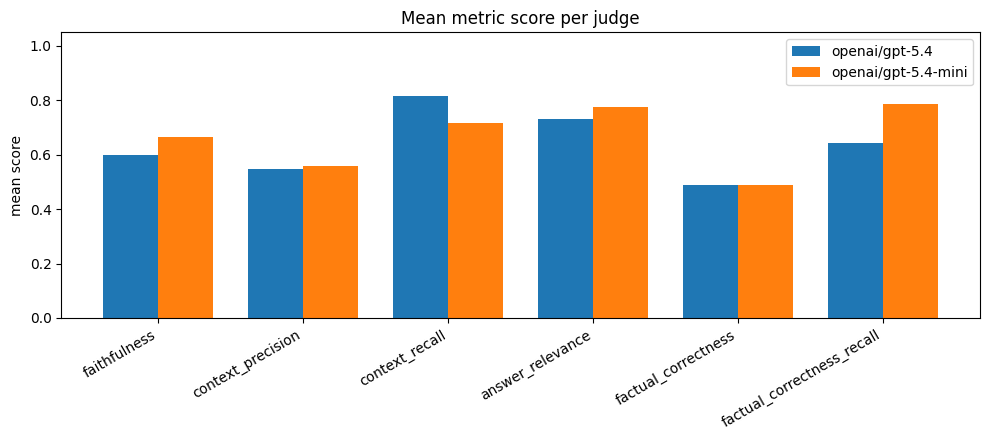

In [30]:
x = np.arange(len(metric_cols_present))
width = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width / 2, overall[JUDGE_LABELS["judge_a"]].values, width, label=JUDGE_LABELS["judge_a"])
ax.bar(x + width / 2, overall[JUDGE_LABELS["judge_b"]].values, width, label=JUDGE_LABELS["judge_b"])
ax.set_xticks(x)
ax.set_xticklabels(metric_cols_present, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("mean score")
ax.set_title("Mean metric score per judge")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Agreement between judges

Per metric:
- **Pearson** correlation — do the judges rank samples similarly on the raw scale?
- **Spearman** correlation — rank-only agreement (robust to scale shifts).
- **MAE** — typical per-sample gap.
- **Exact agreement** — fraction of samples where both judges returned (numerically) the same score. Most useful for the 0/1 metrics.

In [31]:
agreement_rows = []
for c in metric_cols_present:
    a = wide[f"{c}__A"]
    b = wide[f"{c}__B"]
    mask = a.notna() & b.notna()
    a_, b_ = a[mask], b[mask]
    pearson = a_.corr(b_, method="pearson") if len(a_) > 1 else np.nan
    spearman = a_.corr(b_, method="spearman") if len(a_) > 1 else np.nan
    mae = (a_ - b_).abs().mean() if len(a_) else np.nan
    exact = np.isclose(a_, b_).mean() if len(a_) else np.nan
    agreement_rows.append(
        {
            "metric": c,
            "n": int(mask.sum()),
            "pearson": pearson,
            "spearman": spearman,
            "mae": mae,
            "exact_agreement": exact,
        }
    )

agreement_df = pd.DataFrame(agreement_rows).set_index("metric").round(4)
agreement_df

,n,pearson,spearman,mae,exact_agreement
metric,,,,,
faithfulness,15,0.6250,0.5235,0.1599,0.3333
context_precision,20,0.8969,0.9114,0.1014,0.4000
context_recall,20,0.3897,0.4575,0.2000,0.8000
answer_relevance,20,0.8334,0.8125,0.0533,0.4000
factual_correctness,20,0.0815,0.2404,0.2080,0.3000
factual_correctness_recall,19,0.3515,0.4482,0.2158,0.4737


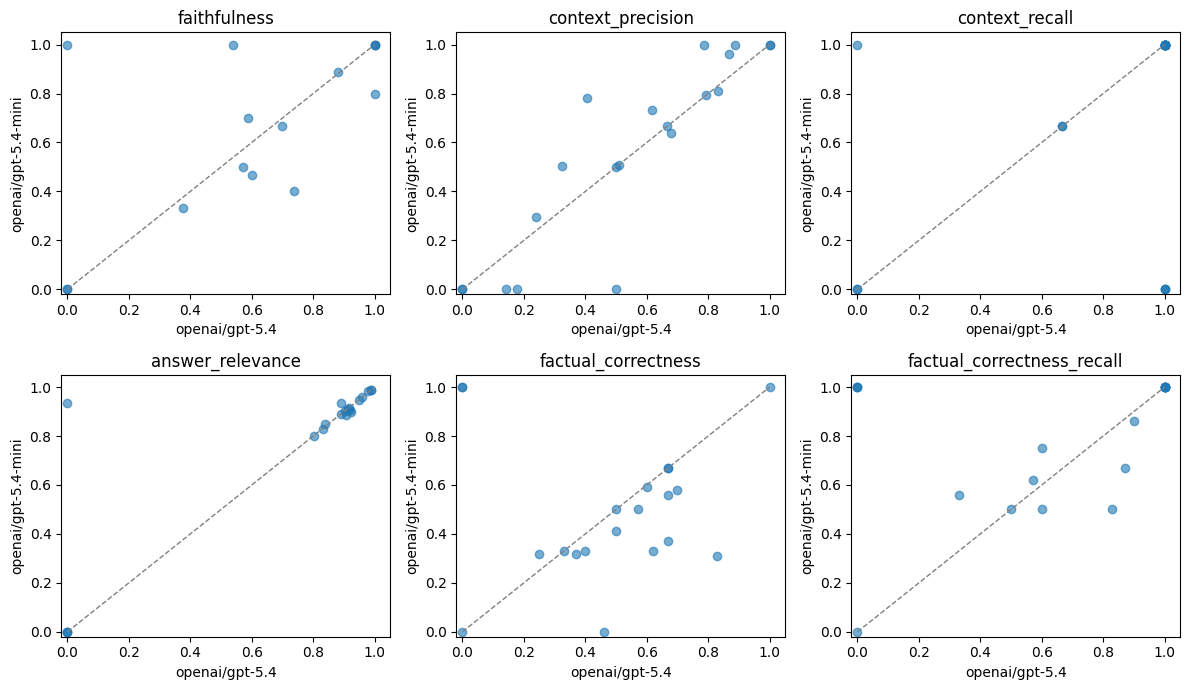

In [32]:
n = len(metric_cols_present)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = np.atleast_2d(axes).ravel()
for i, c in enumerate(metric_cols_present):
    ax = axes[i]
    ax.scatter(wide[f"{c}__A"], wide[f"{c}__B"], alpha=0.6)
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(-0.02, 1.05)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel(JUDGE_LABELS["judge_a"])
    ax.set_ylabel(JUDGE_LABELS["judge_b"])
    ax.set_title(c)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

## 6. Where do the judges disagree most?

In [33]:
TOP_N = 10
for c in metric_cols_present:
    sub = wide[JOIN_KEYS + [f"{c}__A", f"{c}__B", f"{c}__diff"]].copy()
    sub["abs_diff"] = sub[f"{c}__diff"].abs()
    sub = sub.sort_values("abs_diff", ascending=False).head(TOP_N)
    if sub["abs_diff"].max() == 0:
        continue
    print(f"\n=== Top {TOP_N} disagreements: {c} ===")
    display_cols = ["user_input", "subdomain", "question_class", f"{c}__A", f"{c}__B", f"{c}__diff"]
    print(sub[display_cols].to_string(index=False, max_colwidth=80))


=== Top 10 disagreements: faithfulness ===
                                                                      user_input                                                  subdomain question_class  faithfulness__A  faithfulness__B  faithfulness__diff
What is the specific hourly cost for accessing the IQM 50-qubit processor thr...                       nisq_constraints_and_qsd_constraints   unanswerable         0.000000         1.000000            1.000000
If I am using a specialized quantum hardware library that isn't on the autolo...                                        mlflow_tracking_api      reasoning         0.538462         1.000000            0.461538
Can you summarize what kind of data the MLflow Tracking API actually captures...                                        mlflow_tracking_api        summary         0.739130         0.400000           -0.339130
My circuit results are really noisy; does logging T2 times help me figure out... qiskit-specific_experiment_tracking_usi

## 7. Group-level comparison

Mean scores per judge broken down by `question_class` and `subdomain`.

In [34]:
def group_compare(df_wide: pd.DataFrame, group_col: str) -> pd.DataFrame:
    rows = []
    for group_val, sub in df_wide.groupby(group_col, dropna=False):
        for c in metric_cols_present:
            rows.append(
                {
                    group_col: group_val,
                    "metric": c,
                    JUDGE_LABELS["judge_a"]: sub[f"{c}__A"].mean(),
                    JUDGE_LABELS["judge_b"]: sub[f"{c}__B"].mean(),
                    "diff (B - A)": sub[f"{c}__diff"].mean(),
                    "n": len(sub),
                }
            )
    return pd.DataFrame(rows)


by_qclass = group_compare(wide, "question_class")
by_qclass.pivot(index="question_class", columns="metric", values="diff (B - A)").round(4)

metric,answer_relevance,context_precision,context_recall,factual_correctness,factual_correctness_recall,faithfulness
question_class,,,,,,
fact_single,-0.0041,0.0740,0.0,-0.086,0.000,-0.0210
reasoning,0.0052,0.0566,0.2,-0.244,-0.105,0.0427
summary,-0.0035,0.0865,0.0,-0.074,0.036,-0.0736
unanswerable,0.1882,-0.1638,-0.6,0.400,0.600,0.2396


In [35]:
by_subdomain = group_compare(wide, "subdomain")
by_subdomain.pivot(index="subdomain", columns="metric", values="diff (B - A)").round(4)

metric,answer_relevance,context_precision,context_recall,factual_correctness,factual_correctness_recall,faithfulness
subdomain,,,,,,
experiment_tracking_fundamentals,-0.0066,-0.0969,-0.25,0.1800,0.2525,-0.0357
mlflow_tracking_api,-0.0028,-0.0596,0.00,-0.2225,0.0125,0.0297
nisq_constraints_and_qsd_constraints,-0.0000,0.1394,0.00,-0.0100,0.0075,0.2889
qiskit-specific_experiment_tracking_using_mlflow_and_qprov,0.2310,-0.0068,-0.25,-0.2000,0.1675,-0.0588
qprov_provenance_taxonomy,0.0107,0.0904,0.00,0.2475,0.3333,0.0373


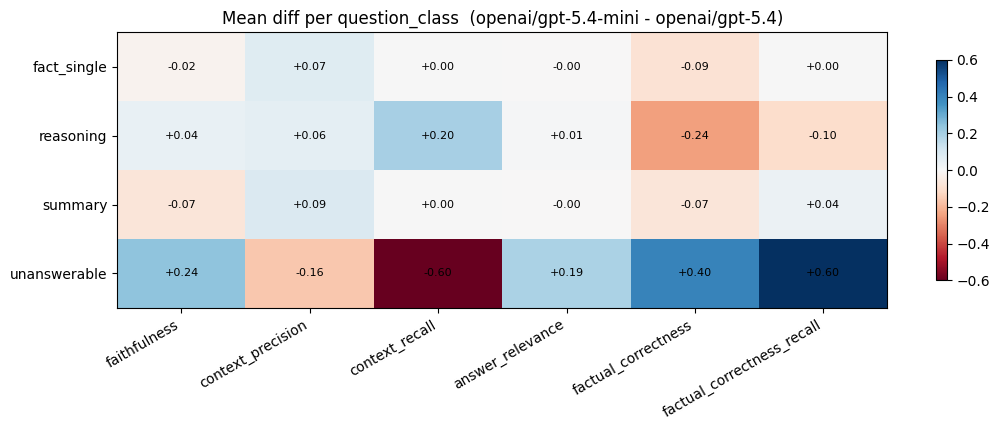

In [36]:
pivot = by_qclass.pivot(index="question_class", columns="metric", values="diff (B - A)")
pivot = pivot.reindex(columns=metric_cols_present)

fig, ax = plt.subplots(figsize=(1.5 * len(metric_cols_present) + 2, 0.6 * len(pivot) + 2))
vmax = float(np.nanmax(np.abs(pivot.values))) or 1e-6
im = ax.imshow(pivot.values, cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8)
ax.set_title(f"Mean diff per question_class  ({JUDGE_LABELS['judge_b']} - {JUDGE_LABELS['judge_a']})")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 8. Distribution of per-sample differences

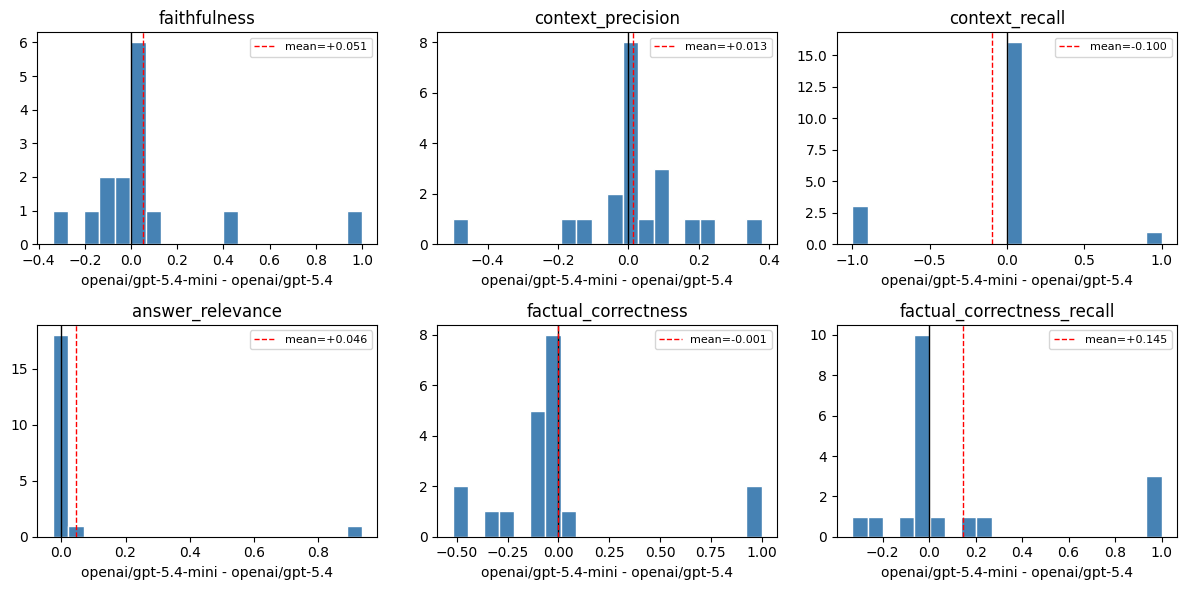

In [37]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.atleast_2d(axes).ravel()
for i, c in enumerate(metric_cols_present):
    ax = axes[i]
    diffs = wide[f"{c}__diff"].dropna()
    ax.hist(diffs, bins=20, color="steelblue", edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(diffs.mean(), color="red", linestyle="--", linewidth=1, label=f"mean={diffs.mean():+.3f}")
    ax.set_title(c)
    ax.set_xlabel(f"{JUDGE_LABELS['judge_b']} - {JUDGE_LABELS['judge_a']}")
    ax.legend(fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

## 9. Export comparison tables

In [38]:
# Uncomment to write the wide comparison frame and summary tables to disk.
# wide.to_csv("judge_comparison_per_sample.csv", index=False)
# overall.to_csv("judge_comparison_overall.csv")
# agreement_df.to_csv("judge_comparison_agreement.csv")
# by_qclass.to_csv("judge_comparison_by_qclass.csv", index=False)
# by_subdomain.to_csv("judge_comparison_by_subdomain.csv", index=False)
print("Done.")

Done.
